# With dataset
- fake dataset, now not only overfit one example/batch but learn viable registration

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

from constraints.generators import AffineSampleBound, ArteryGeneratorAffine, ROT_ONLY
from constraints.visu.helpers import show_torch_image
from constraints.transforms import differentiable_rotation
from constraints.models.affine import TwoBranch
from constraints.losses import CentroidLoss
from torch.utils.data import DataLoader
from constraints.transforms import differentiable_rigid

import torch
import pytorch_lightning as pl


In [3]:
class LitTwoBranch(pl.LightningModule):
    def __init__(self, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = TwoBranch()
        self.segmentation_loss = torch.nn.CrossEntropyLoss()
        self.registration_loss = CentroidLoss()

    def forward(self, images):
        return self.model(images)

    def _shared_step(self, batch, stage):
        images = batch['img']
        masks = batch['mask']
        templates = batch['template']

        pred_mask, angles,translations = self.model(images)
        rotated_template = differentiable_rigid(templates, angles, dx=translations[:, 0], dy=translations[:, 1])

        seg_loss = self.segmentation_loss(pred_mask, masks.argmax(dim=1))
        reg_loss = self.registration_loss(masks, rotated_template)
        loss = seg_loss + reg_loss

        batch_size = images.size(0)
        self.log(f'{stage}_loss', loss, on_step=False, on_epoch=True, prog_bar=True, batch_size=batch_size)
        self.log(f'{stage}_seg_loss', seg_loss, on_step=False, on_epoch=True, batch_size=batch_size)
        self.log(f'{stage}_reg_loss', reg_loss, on_step=False, on_epoch=True, batch_size=batch_size)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, 'train')

    def validation_step(self, batch, batch_idx):
        self._shared_step(batch, 'val')

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)





# Rotation only

In [4]:
trn_dataset = ArteryGeneratorAffine(fixed_seed=42,sample_specs=ROT_ONLY,num_samples=1000,speckle=0.1)
val_dataset = ArteryGeneratorAffine(fixed_seed=23, sample_specs=ROT_ONLY, num_samples=100, speckle=0.2)

In [5]:
BATCH_SIZE = 32
EPOCHS = 10
trn_loader = DataLoader(trn_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
model = LitTwoBranch(lr=1e-3)

In [14]:
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator='auto',
    devices='auto',
    logger=False,
    enable_checkpointing=False,
    log_every_n_steps=1,
)
trainer.fit(model, train_dataloaders=trn_loader, val_dataloaders=val_loader)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name              | Type             | Params | Mode 
---------------------------------------------------------------
0 | model             | TwoBranch        | 14.3 M | train
1 | segmentation_loss | CrossEntropyLoss | 0      | train
2 | registration_loss | CentroidLoss     | 0      | train
---------------------------------------------------------------
14.3 M    Trainable params
0         Non-trainable params
14.3 M    Total params
57.290    Total estimated model params size (MB)
146       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/mnt/appl/software/IPython/9.3.0-GCCcore-14.2.0/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3680: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
from pathlib import Path

save_dir = Path("outputs")
save_dir.mkdir(exist_ok=True)

for ex_id in range(10):
    example = val_dataset[ex_id]
    img = example['img']
    mask = example['mask']
    template = example['template']
    if ex_id == 0:
        show_torch_image(template, save_path=save_dir / f"example_{ex_id}_template.png")

    model.eval()
    with torch.no_grad():
        pred_mask, angle,_ = model(img.unsqueeze(0))
        rotated_template = differentiable_rotation(template.unsqueeze(0), angle)

    show_torch_image(img,save_path=save_dir / f"example_{ex_id}_input.png")
    show_torch_image(mask.argmax(dim=0), save_path=save_dir / f"example_{ex_id}_mask.png")
    show_torch_image(pred_mask.argmax(dim=1).squeeze(), save_path=save_dir / f"example_{ex_id}_pred.png")
    show_torch_image(rotated_template.squeeze(), save_path=save_dir / f"example_{ex_id}_rotated.png")

# ROT and shift

In [7]:
trn_dataset = ArteryGeneratorAffine(fixed_seed=42,num_samples=1000,speckle=0.1)
val_dataset = ArteryGeneratorAffine(fixed_seed=23, num_samples=100, speckle=0.2)

torch.Size([1, 256, 256])


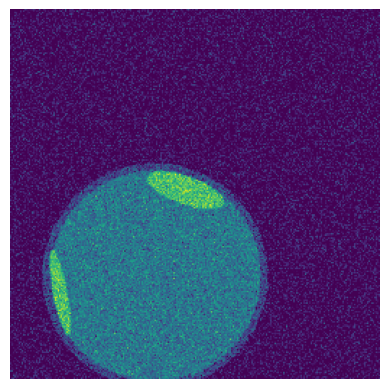

In [17]:
dc = trn_dataset[0]
dc.keys()
print(dc["img"].shape)
show_torch_image(dc["img"],save_path="./test.png")


In [8]:
BATCH_SIZE = 32
EPOCHS = 30
trn_loader = DataLoader(trn_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
model = LitTwoBranch(lr=1e-3)

In [7]:
from pathlib import Path
save_dir = Path("./notebooks/outputs/affine_test_generator")


save_dir.mkdir(exist_ok=True)
trainer = pl.Trainer(
    max_epochs=EPOCHS,
    accelerator='auto',
    devices='auto',
    enable_checkpointing=False,
    log_every_n_steps=1, 
    logger=True
)
trainer.fit(model, train_dataloaders=trn_loader, val_dataloaders=val_loader)


/mnt/appl/software/PyTorch-Lightning/2.5.5-foss-2025a-CUDA-12.8.0/lib/python3.13/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/mrkosmic/.local/lib/python3.13/site-packages/i ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/mnt/appl/software/PyTorch-Lightning/2.5.5-foss-2025a-CUDA-12.8.0/lib/python3.13/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:493: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accurate number, set `self.example_input_array` in your LightningModule.

  | Name              | Type             | Params | Mode 
--------------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/mnt/appl/software/PyTorch-Lightning/2.5.5-foss-2025a-CUDA-12.8.0/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/mnt/appl/software/PyTorch-Lightning/2.5.5-foss-2025a-CUDA-12.8.0/lib/python3.13/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [ ]:
from pathlib import Path


save_dir = Path("./notebooks/outputs/affine_test_generator")

save_dir.mkdir(exist_ok=True)

for ex_id in range(10):
    example = val_dataset[ex_id]
    img = example['img']
    mask = example['mask']
    template = example['template']
    if ex_id == 0:
        show_torch_image(template, save_path=save_dir / f"example_{ex_id}_template.png")

    model.eval()
    with torch.no_grad():
        pred_mask, angle,translations = model(img.unsqueeze(0))
        rotated_template = differentiable_rigid(template.unsqueeze(0), angle, dx=translations[:, 0], dy=translations[:, 1])

    show_torch_image(img,save_path=save_dir / f"example_{ex_id}_input.png",cmap="gray")
    show_torch_image(mask.argmax(dim=0), save_path=save_dir / f"example_{ex_id}_mask.png")
    show_torch_image(pred_mask.argmax(dim=1).squeeze(), save_path=save_dir / f"example_{ex_id}_pred.png")
    show_torch_image(rotated_template.squeeze(), save_path=save_dir / f"example_{ex_id}_rotated.png")